In [58]:
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from pathlib import Path
from sklearn.linear_model import LinearRegression

In [2]:
ZONE = "PER+Coronel Portillo"

In [3]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [4]:
df_area = pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv").set_index("label").T
df_area.index = [int(idx) + 2000 for idx in df_area.index]

In [129]:
df_transition_avg = 0
nyears = 10
for year in range(2022 - nyears, 2022):
    df_transition = pd.read_csv(out_path / "small" / "transition" / "table_frac" / f"{year}_{year + 1}" / f"{ZONE}.csv").set_index("start")
    df_transition_avg += df_transition

df_transition_avg /= nyears

In [141]:
def predict_areas(df_transition: pd.DataFrame, start_areas: pd.Series) -> pd.Series:
    new_areas = dict.fromkeys(LABEL_LIST, 0.0)
    for start in LABEL_LIST:
        for end in LABEL_LIST:
            if start not in start_areas.index:
                continue
            new_areas[end] += start_areas[start] * df_transition.loc[start, end]

    return pd.Series(new_areas)

In [142]:
future_areas = [predict_areas(df_transition_avg, df_area.loc[2022]).rename(2023)]

for year in range(2024, 2031):
    start_areas = future_areas[-1]
    future_areas.append(predict_areas(df_transition_avg, start_areas).rename(year))

future_areas = pd.concat(future_areas, axis=1).T

Label forests_mangroves not found in the DataFrame.


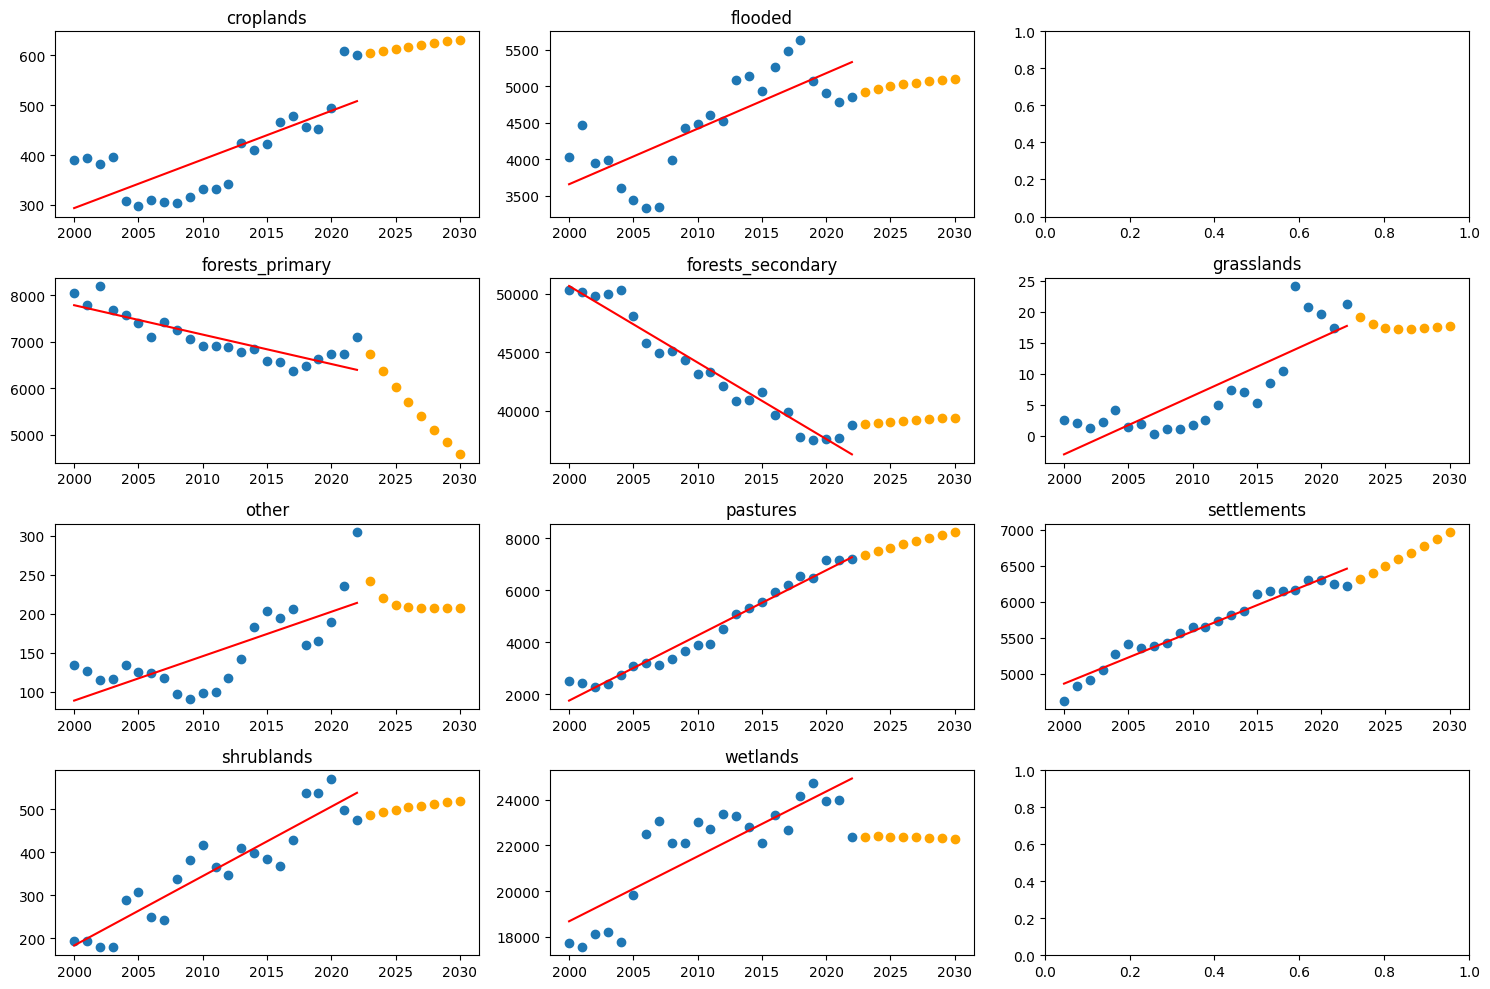

In [143]:
fig, ax = plt.subplots(4, 3, figsize=(15, 10))

X = df_area.index.to_numpy().reshape(-1, 1)
for label, ax in zip(LABEL_LIST, ax.flatten()):
    try:
        y = df_area[label].to_numpy()
    except KeyError:
        print(f"Label {label} not found in the DataFrame.")
        continue

    coef = np.polyfit(X.flatten(), y, 1)
    yhat = np.polyval(coef, X.flatten())

    ax.scatter(X, y)
    ax.plot(X, yhat, color="red")

    ax.scatter(future_areas.index, future_areas[label], color="orange", label="Future")
    ax.set_title(label)
fig.tight_layout()

In [35]:
def derive_coef(x: float, orig_coef: np.ndarray, scale: float) -> np.ndarray:
    fast_slope = coef[0] * scale
    fast_intersect = np.polyval(orig_coef, x) - fast_slope * x
    return np.array([fast_slope, fast_intersect])


def predict_scaled(x: float, orig_coef: np.ndarray, scale: float) -> float:
    coef = derive_coef(x[0], orig_coef, scale)
    return np.polyval(coef, x)

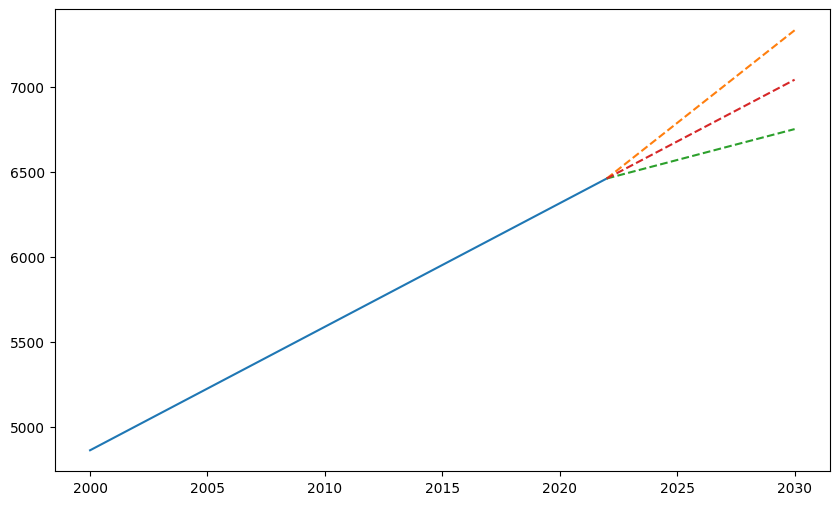

In [49]:
x = X.flatten()
x_future = np.arange(2022, 2031)

yhat = np.polyval(coef, x)
pred_fast = predict_scaled(x_future, coef, 1.5)
pred_slow = predict_scaled(x_future, coef, 0.5)
pred_normal = predict_scaled(x_future, coef, 1.0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, yhat)
ax.plot(x_future, pred_fast, linestyle="--")
ax.plot(x_future, pred_slow, linestyle="--")
ax.plot(x_future, pred_normal, linestyle="--")